
# Linear Regression — Practical Project

## Objective

Learn how to build a linear regression model using real-world data.

## What the Practical Assignment Includes


1. Load the dataset and explore its structure.
2. Analyze the data and perform exploratory data analysis (EDA).
3. Split the data into training and testing sets.
4. Build a linear regression model using the scikit-learn library.
5. Evaluate the model's performance using MSE (Mean Squared Error) and MAE (Mean Absolute Error).


### 1. Importing Libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 2. Loading the Data

In [2]:
df = pd.read_csv('data/sales.csv')
df.head()

,SalePrice,GrLivArea,GarageArea,OverallQual,Street,SaleCondition
0,208500,1710,548,7,Pave,Normal
1,181500,1262,460,6,Pave,Normal
2,223500,1786,608,7,Pave,Normal
3,140000,1717,642,7,Pave,Abnorml
4,250000,2198,836,8,Pave,Normal


### 3. Exploratory Data Analysis
1. Analyze the data and examine individual plots showing the relationship between the target variable and each feature. If the dataset contains a relatively small number of features, it can be useful to create a `sns.pairplot`.
2. Encode categorical features, for example, using `pd.get_dummies`.
3. Consider whether additional features can be created from the existing variables.
4. Draw preliminary conclusions based on the analysis.

In [3]:
df.info

<bound method DataFrame.info of       SalePrice  GrLivArea  GarageArea  OverallQual Street SaleCondition
0        208500       1710         548            7   Pave        Normal
1        181500       1262         460            6   Pave        Normal
2        223500       1786         608            7   Pave        Normal
3        140000       1717         642            7   Pave       Abnorml
4        250000       2198         836            8   Pave        Normal
...         ...        ...         ...          ...    ...           ...
1455     175000       1647         460            6   Pave        Normal
1456     210000       2073         500            6   Pave        Normal
1457     266500       2340         252            7   Pave        Normal
1458     142125       1078         240            5   Pave        Normal
1459     147500       1256         276            5   Pave        Normal

[1460 rows x 6 columns]>

In [4]:
df.describe()

,SalePrice,GrLivArea,GarageArea,OverallQual
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,1515.463699,472.980137,6.099315
std,79442.502883,525.480383,213.804841,1.382997
min,34900.000000,334.000000,0.000000,1.000000
25%,129975.000000,1129.500000,334.500000,5.000000
50%,163000.000000,1464.000000,480.000000,6.000000
75%,214000.000000,1776.750000,576.000000,7.000000
max,755000.000000,5642.000000,1418.000000,10.000000


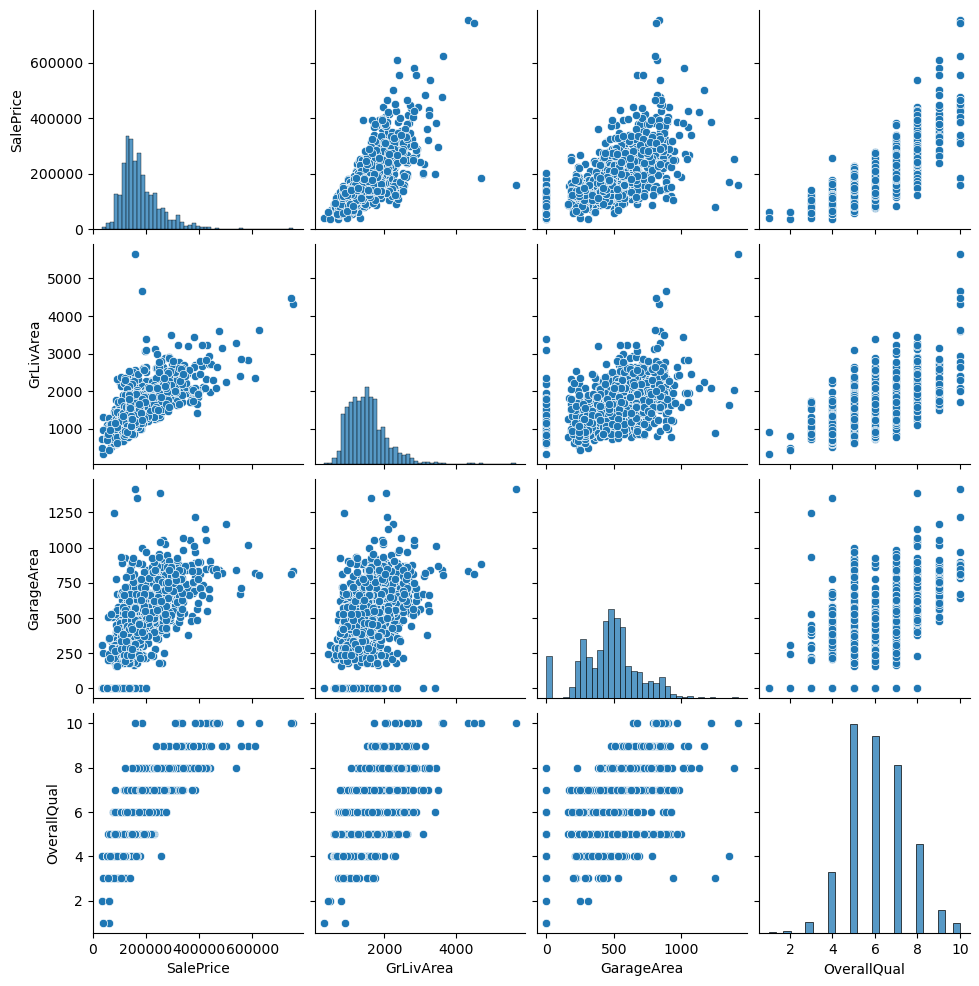

In [5]:
sns.pairplot(df[['SalePrice', 'GrLivArea', 'GarageArea', 'OverallQual']])
plt.show()

It can be observed that as the living area (`GrLivArea`) increases, the house price (`SalePrice`) tends to increase as well. Higher overall quality (`OverallQual`) is also associated with a higher house price.

Distribution of House Prices

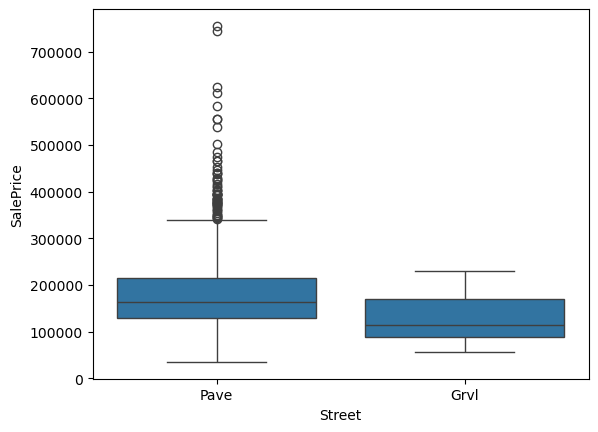

In [8]:
sns.boxplot(data=df, x='Street', y='SalePrice')
plt.show()

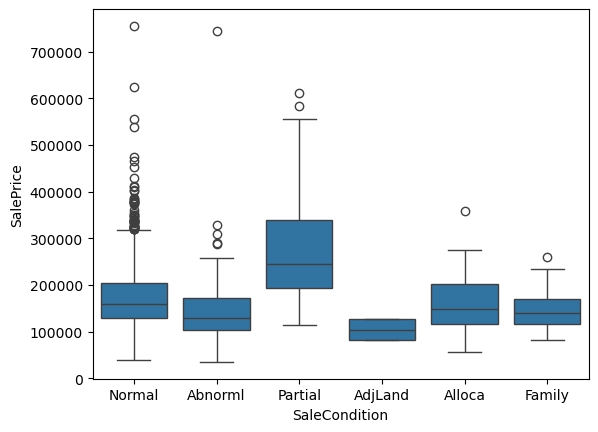

In [9]:
sns.boxplot(data=df, x='SaleCondition', y='SalePrice')
plt.show()

Encoding Categorical Features

> The boxplots show that the categorical features `Street` and `SaleCondition` affect the distribution of the target variable `SalePrice`. Houses with the `Pave` street type tend to have higher prices on average than houses with `Grvl`. Among the sale conditions, the `Partial` category has the highest median price, while `AdjLand` has the lowest. The plots also show a significant number of outliers, especially among more expensive houses. Therefore, categorical features should be taken into account when building the model and encoded beforehand.

In [10]:
df = pd.get_dummies(df, columns=['Street', 'SaleCondition'], drop_first=True)

**Creating an Additional Binary Feature — Garage Availability**

`0` — no garage, `1` — garage available.


In [11]:
df['HasGarage'] = (df['GarageArea']>0).astype(int)

### 4. Splitting the Data into Training and Testing Sets

In [12]:
# Ваш код здесь
from sklearn.model_selection import train_test_split

In [13]:
features = ['GrLivArea', 'GarageArea', 'OverallQual',
            'Street_Pave', 'SaleCondition_AdjLand',
            'SaleCondition_Alloca', 'SaleCondition_Family',
            'SaleCondition_Normal', 'SaleCondition_Partial']

X = df[features]
y = df['SalePrice']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=123)

### 5. Обучение модели линейной регрессии

Дополнительно можно взглянуть на коэффициенты и смещение обученной модели.

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

LinearRegression()

### 6. Generating Predictions for the Training and Testing Sets

In [18]:
y_predict_train = model.predict(X_train)
y_predict_test = model.predict(X_test)

### 7. Evaluating the Predictions

1. Evaluate the model's performance on the training and testing sets using MAE and MSE.
2. Create a scatter plot comparing the actual target values with the predicted values.

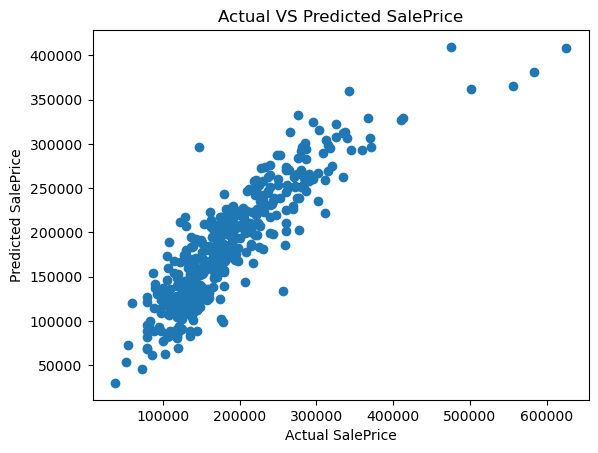

In [19]:
plt.scatter(y_test, y_predict_test)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual VS Predicted SalePrice')
plt.show()

MSE

In [20]:
from sklearn.metrics import mean_squared_error

In [38]:
train_mse = mean_squared_error(y_train, y_predict_train)
test_mse = mean_squared_error(y_test, y_predict_test)

print(f'Train MSE: {format(train_mse)}')
print(f'Test MSE: {format(test_mse)}')

Train MSE: 1719170723.5914984
Test MSE: 1272655239.1540682


MAE

In [39]:
from sklearn.metrics import mean_absolute_error

In [40]:
train_mae = mean_absolute_error(y_train, y_predict_train)
test_mae = mean_absolute_error(y_test, y_predict_test)

print(f'Train MAE: {format(train_mae)}')
print(f'Test MAE: {format(test_mae)}')

Train MAE: 27033.69768697217
Test MAE: 25115.715860848893


> The Mean Absolute Error (MAE) on the test set is approximately 25,116, which means that the model's predictions differ from the actual house prices by about 25,000 on average. The error values for the training and test sets are relatively close, indicating that there is no significant overfitting.

In [41]:
print(y_test.mean())

182973.16173120728


**Error Percentage**

In [43]:
print(test_mae / y_test.mean() * 100)

13.726447979154772


> The model's Mean Absolute Percentage Error (MAPE) is approximately 13.7%, meaning that the predicted house price differs from the actual price by about 14% on average. For evaluating the model, we primarily consider MAE because MSE is sensitive to outliers: when calculating MSE, errors are squared, giving significantly more weight to large errors. Our dataset contains outliers, such as houses with exceptionally high prices. Therefore, MAE better represents the average prediction error and is a more appropriate metric in this case.